# Find all survey intersections

This notebooks demonstrates the `network` method of finding crossovers or intersections between all the flights or lines of a survey. See the past notebooks for more details on the specifics of finding crossovers.

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This is a subset of the PolarGAP survey over Antarctica's south pole. The file is downloaded and processed in the notebook `PolarGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey.csv")

data_df = data_df.drop(columns="line")

data_df = data_df[
    [
        "easting",
        "northing",
        "Elev",
        "distance_along_flight",
        "unixtime",
        "flight",
    ]
]

data_df = data_df.sort_values(["flight", "unixtime"])
data_df = data_df.dropna(how="any")

# only use every 5th point to speed up the notebook
data_df = data_df[::5]

# for testing, only use some flights
data_df = data_df[~data_df.flight.isin([1, 5, 8])]
data_df = data_df[
    data_df.flight.isin(data_df.flight.unique()[data_df.flight.unique() % 2 == 0])
]

# rename flights sequentially from 1
data_df["flight"] = airbornegeo.unique_line_id(
    data_df,
    line_col_name="flight",
)

data_df.head()

,easting,northing,Elev,distance_along_flight,unixtime,flight
16695,251909.790765,673168.965977,2644.17,79.538062,1.450281e+09,1
16700,252074.298805,673295.701903,2658.10,287.204899,1.450281e+09,1
16705,252242.155717,673426.287316,2680.62,499.876569,1.450281e+09,1
16710,252410.711778,673556.825421,2705.80,713.070226,1.450281e+09,1
16715,252575.608972,673690.928756,2728.37,925.624098,1.450281e+09,1


This subset of the survey has 17 flights, which can't be categorized into groups due to the unconventional survey design. This means we can't use the `groups` method to define crossovers, but need the `network` method.You can see the flight names using the  `unique()` method of pandas. We plot the data below and label each flight with it's name.

In [3]:
data_df.flight.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

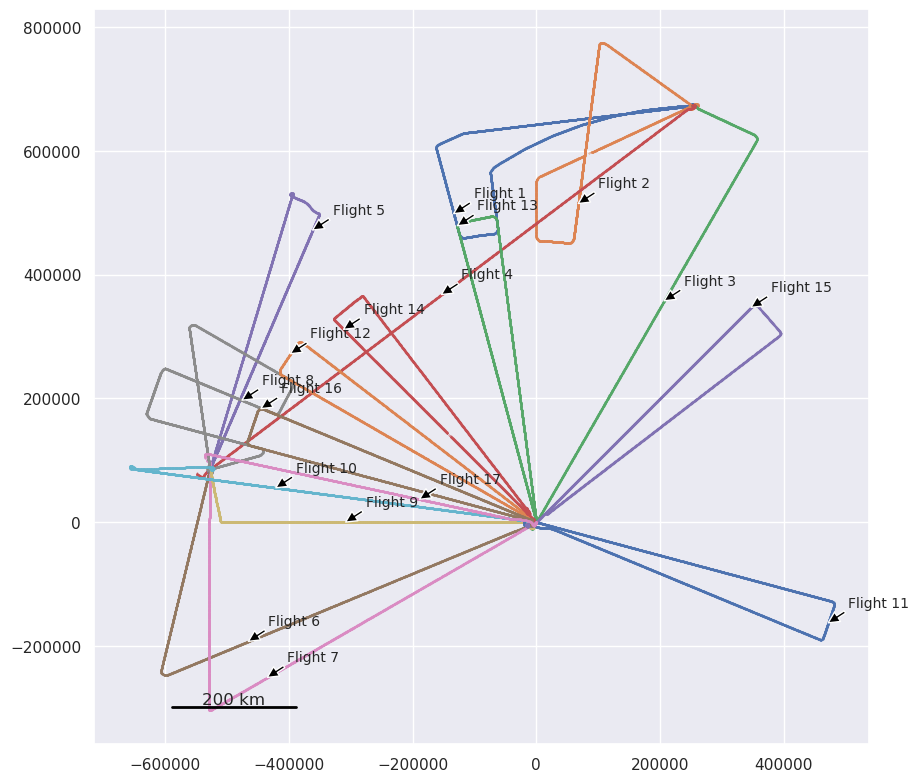

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
for name, line_data in data_df.groupby("flight"):
    # plot points
    ax.scatter(
        line_data.easting,
        line_data.northing,
        s=0.1,
    )
    # location for label
    label_point = line_data.iloc[len(line_data) // 2]
    ax.annotate(
        f"Flight {name}",
        xy=(label_point.easting, label_point.northing),
        xycoords="data",
        xytext=(20, 20),
        textcoords="offset pixels",
        fontsize=10,
        arrowprops={
            "facecolor": "black",
            "headwidth": 8,
            "headlength": 8,
            "width": 2,
        },
        ha="left",
        va="center",
    )
ax.set_aspect("equal")
airbornegeo.add_scalebar(ax, 200e3)

## Calculate intersections between all flights
We want to calculate the theoretical intersection points between all combinations of flights. 

First we need to convert our dataframe into a geodataframe.

In [5]:
# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

In [6]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="flight",
    method="network",
)
inters

Line pairs:   0%|          | 0/136 [00:00<?, ?it/s]

INFO:airbornegeo:found 166 intersections


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,1,2,False,POINT (249372 674403),249372.0,674403.0,189.041094
1,1,2,False,POINT (85987 653161),85987.0,653161.0,93.636198
2,1,2,False,POINT (84975 645460),84975.0,645460.0,135.165260
3,1,2,False,POINT (250173 673830),250173.0,673830.0,132.644825
4,1,2,False,POINT (251993 673233),251993.0,673233.0,102.669491
...,...,...,...,...,...,...,...
161,15,16,False,POINT (-8413 -5274),-8413.0,-5274.0,73.122757
162,15,16,False,POINT (-9141 -3422),-9141.0,-3422.0,123.990722
163,15,16,False,POINT (-4711 -3406),-4711.0,-3406.0,147.106743
164,15,17,False,POINT (-1484 -2427),-1484.0,-2427.0,17.719184


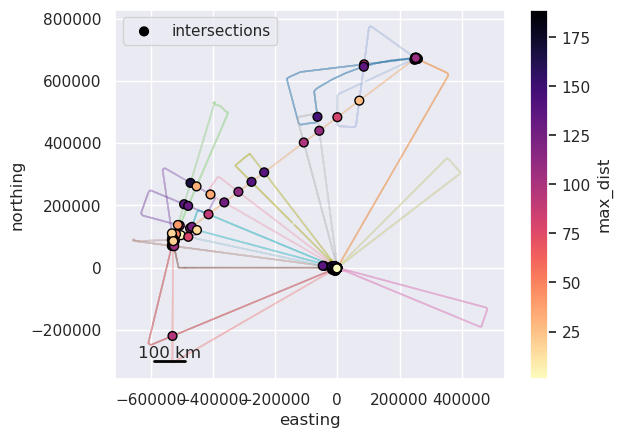

In [7]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.001,
    marker=".",
    cmap="tab20",
    colorbar=False,
)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=40,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersections",
)
airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

We can analyze the `max_dist` values to see if there are any outlier crossovers which are really far from the nearest data.

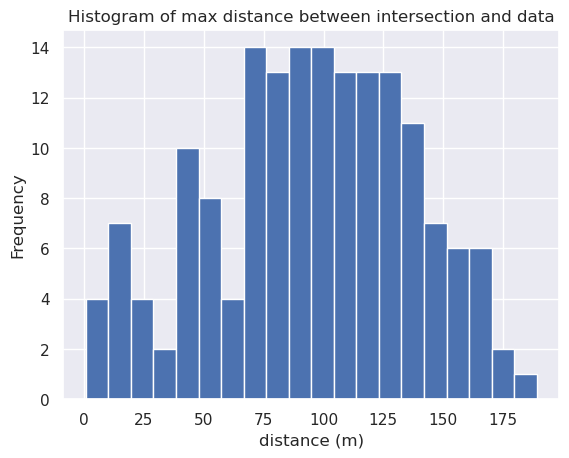

In [8]:
ax = inters.max_dist.plot.hist(bins=20)
ax.set_xlabel("distance (m)")
ax.set_title("Histogram of max distance between intersection and data");

In [9]:
# We can see which lines don't have any intersections.
airbornegeo.lines_without_intersections(data_df, inters, line_column="flight")

[]

## Dealing with duplicate intersections

If lines cross over each other often, they can produce many intersections in a similar region. We can find these duplicates with pandas.

In [10]:
inters[
    inters.duplicated(subset=["line1", "line2"], keep=False)
]  # [['line1','line2']].to_numpy()

,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,1,2,False,POINT (249372 674403),249372.0,674403.0,189.041094
1,1,2,False,POINT (85987 653161),85987.0,653161.0,93.636198
2,1,2,False,POINT (84975 645460),84975.0,645460.0,135.165260
3,1,2,False,POINT (250173 673830),250173.0,673830.0,132.644825
4,1,2,False,POINT (251993 673233),251993.0,673233.0,102.669491
...,...,...,...,...,...,...,...
159,15,16,False,POINT (-1711 -2762),-1711.0,-2762.0,120.301800
160,15,16,False,POINT (-4479 -3763),-4479.0,-3763.0,114.465545
161,15,16,False,POINT (-8413 -5274),-8413.0,-5274.0,73.122757
162,15,16,False,POINT (-9141 -3422),-9141.0,-3422.0,123.990722


The below map show the issue where we have several intersections within a few kilometers of each other between flights 2 and 4, but we also have of other valid duplicates which we want to retain.

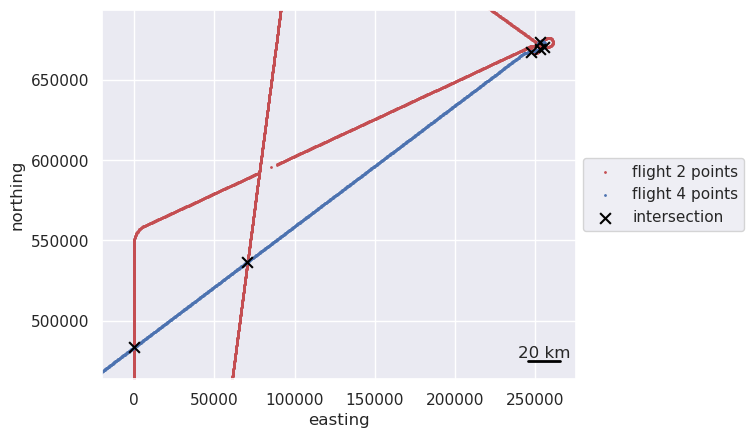

In [11]:
# zoom in on duplicated intersections
dup_inters = inters[(inters.line1 == 2) & (inters.line2 == 4)]
reg = vd.get_region((dup_inters.easting, dup_inters.northing))
reg = vd.pad_region(reg, 20e3)

inter = dup_inters.iloc[0]
ax = data_df[data_df.flight == inter.line1].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=1,
    label=f"flight {inter.line1} points",
)
ax = data_df[data_df.flight == inter.line2].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=1,
    ax=ax,
    label=f"flight {inter.line2} points",
)
dup_inters.plot.scatter(
    "easting",
    "northing",
    color="black",
    s=60,
    marker="x",
    ax=ax,
    label="intersection",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 20e3, "bottom right")
ax.set_aspect("equal")

If we rerun the function with the `block_size` parameter, we can see we've reduce the duplicate intersections within 10km of each other, while retaining the other duplicates.

In [12]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="flight",
    method="network",
    block_size=10e3,  # only keep 1 duplicate intersection in each 10km block
)
inters[(inters.line1 == 2) & (inters.line2 == 4)]

Line pairs:   0%|          | 0/136 [00:00<?, ?it/s]

INFO:airbornegeo:found 99 intersections


,line1,line2,is_buffered,geometry,easting,northing,max_dist
6,2,4,False,POINT (255259 670368),255259.0,670368.0,26.277755
7,2,4,False,POINT (70593 536540),70593.0,536540.0,26.892328
8,2,4,False,POINT (16 483360),16.0,483360.0,80.548492


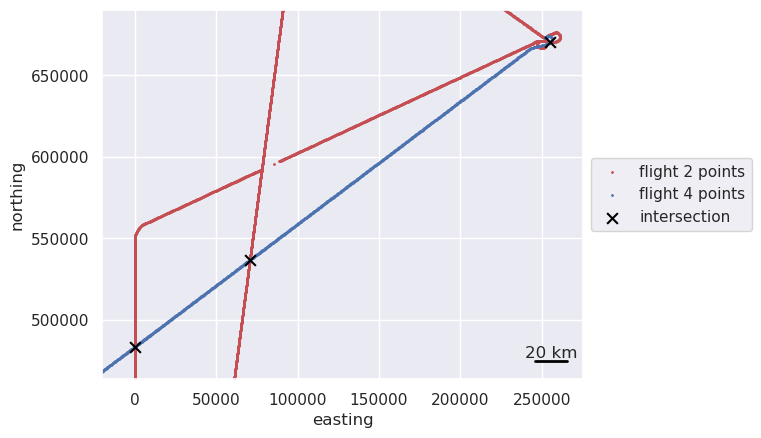

In [13]:
# zoom in on duplicated intersections
dup_inters = inters[(inters.line1 == 2) & (inters.line2 == 4)]

reg = vd.get_region((dup_inters.easting, dup_inters.northing))
reg = vd.pad_region(reg, 20e3)

inter = dup_inters.iloc[0]
ax = data_df[data_df.flight == inter.line1].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=1,
    label=f"flight {inter.line1} points",
)
ax = data_df[data_df.flight == inter.line2].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=1,
    ax=ax,
    label=f"flight {inter.line2} points",
)
dup_inters.plot.scatter(
    "easting",
    "northing",
    color="black",
    s=60,
    marker="x",
    ax=ax,
    label="intersection",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")

airbornegeo.add_scalebar(ax, 20e3, "bottom right")
ax.set_aspect("equal")